<p class="mlx-kicker">Part III &middot; Training recipe &middot; Chapter 11</p>

# 11. Initialization and regularization: from Xavier to muP

<dl class="mlx-meta"><div><dt>Level</dt><dd>Intermediate</dd></div><div><dt>Reading</dt><dd>about 25 min</dd></div><div><dt>Hands-on</dt><dd>about 6 min on a laptop CPU</dd></div><div><dt>You should know</dt><dd>Chapter 5 (activations), chapter 9 (Adam), variance of a sum</dd></div></dl>

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daiyip/ml-explained/blob/main/chapters/11-initialization/index.ipynb)

![Three generations of keeping a network trainable. Each column highlights what is new: weights scaled by their fan-in so the signal keeps its size through depth, random noise and shrinkage during training so the model cannot memorize, and initialization and learning rates scaled with width so the best settings carry over from a small model to a large one.](figures/init-lineage.svg)

## What changed, and why it works

Before the first gradient step, a network is just a stack of random matrices. Whether it can learn at all depends on one number per layer: how much each layer scales the size of the signal passing through it, forward and backward. If that factor is a little above 1, the signal explodes over 30 layers; a little below 1, it vanishes. This chapter follows three answers to the question *why does signal scale at step zero decide trainability?*, plus the regularizers that keep a trainable network from memorizing its data.

<div class="mlx-why">
<section class="mlx-why__card mlx-why__card--1"><p class="mlx-why__n">1 &middot; Xavier and He</p><h3>Scale each layer's weights by its fan-in</h3><p><b>What changed.</b> Weights stopped being drawn with a hand-picked spread such as 0.01 or 1. Glorot and Bengio (2010) set their variance to 2 / (fan-in + fan-out); He et al. (2015) doubled it to 2 / fan-in for ReLU.</p><p><b>Why it works.</b> A unit sums fan-in random terms, so the variance of its output is fan-in times the weight variance times the input variance. Choosing the weight variance as 1 / fan-in makes that product 1, and the signal keeps its size layer after layer. ReLU zeroes half of its inputs, which halves the variance, so He puts the factor 2 back.</p><p class="mlx-why__run">Our runs, 30-layer ReLU MLP: Xavier signal falls to 2&times;10<sup>-5</sup> of its size, He keeps about half; only He trains (98% accuracy)</p></section>
<section class="mlx-why__card mlx-why__card--2"><p class="mlx-why__n">2 &middot; Dropout and weight decay</p><h3>Add noise and shrinkage during training</h3><p><b>What changed.</b> Dropout (Hinton et al., 2012) sets a random fraction of hidden units to zero at every training step. Weight decay pulls every weight a little towards zero at every step.</p><p><b>Why it works.</b> A network that can be trained can also memorize its training set. Dropout means no unit can rely on a specific partner being present, so the network has to spread each feature over many units, which behaves like an average of many thinned networks. Weight decay makes large weights costly, which favours smoother functions that change less between nearby inputs.</p><p class="mlx-why__run">Our run, 20k characters: best validation loss 2.756 without regularization, 2.529 with dropout 0.5, 2.576 with weight decay</p></section>
<section class="mlx-why__card mlx-why__card--3"><p class="mlx-why__n">3 &middot; muP</p><h3>Scale initialization and learning rate with width</h3><p><b>What changed.</b> The Maximal Update Parametrization (Yang and Hu, 2021; Yang et al., 2022) keeps fan-in initialization but divides the learning rate of hidden matrices by the width and starts the output layer at zero.</p><p><b>Why it works.</b> Fan-in scaling fixes the size of the signal at step zero, not the size of each update. Under Adam every weight moves by about the learning rate, and a unit sums width many such moves that all point the same way, so the effect of one step grows with width. Dividing the learning rate by the width cancels that, and the best learning rate stops depending on model size.</p><p class="mlx-why__run">Our sweep, widths 64 to 1024: best LR 2<sup>-7</sup>, 2<sup>-8</sup>, 2<sup>-9</sup> with standard scaling, 2<sup>-7</sup> at every width with muP</p></section>
</div>

Read left to right, the question moves from *can the network train at all*, to *does what it learns generalize*, to *can we tune a small network and trust the settings on a large one*. The first and third are the same idea applied twice: control the scale of the signal, first at step zero, then at every step.

## Evolution path

| Year | Step | Level | What changed |
| --- | --- | --- | --- |
| 1998 | LeCun initialization | minor | weight variance 1 / fan-in for tanh-like units, in "Efficient BackProp" |
| 2010 | Xavier (Glorot) initialization | **major** | variance 2 / (fan-in + fan-out): balance the forward and backward pass |
| 2012 | Dropout, data augmentation | **major** | random units zeroed during training; AlexNet also trains on random crops and flips |
| 2013-2014 | Orthogonal initialization | minor | random orthogonal matrices preserve every direction exactly (Saxe et al.) |
| 2015 | He (Kaiming) initialization | **major** | variance 2 / fan-in: correct for ReLU discarding half the signal |
| 2015 | BatchNorm, later LayerNorm | minor | normalization makes deep nets far less sensitive to init (chapter 6) |
| 2017-2019 | AdamW, scaled residual init | minor | decoupled weight decay (chapter 9); GPT-2 and Fixup shrink residual branches by depth |
| 2022 | muP | **major** | per-layer init and learning rate scaled with width, so hyperparameters transfer |
| 2020s | Dropout fades in LLM pretraining | minor | one pass over huge data leaves little to memorize; weight decay stays |

## The lineage post-mortem: what drove each replacement?

| Replacement | Pressure that drove it | What it bought |
| --- | --- | --- |
| fixed small weights to Xavier | deep tanh and sigmoid nets did not train from random starts | a signal that keeps its size through depth, without layer-wise pre-training |
| Xavier to He | ReLU halves the variance at every layer | trainable 30-layer ReLU networks from scratch |
| no regularizer to dropout and weight decay | big nets memorized small labelled datasets | a smaller gap between training and validation loss |
| hand-tuned LR per size to muP | each new model size needed a fresh, expensive learning-rate search | tune once on a small proxy, reuse the settings on the big model |

The first two rows are about the forward and backward signal at step zero, and they are close to solved: fan-in scaling plus normalization (chapter 6) plus residual connections (chapter 7) make depth safe. The third row has shifted with the data regime. Dropout was essential when datasets were small, and it is often switched off in LLM pretraining, which sees each token about once. The fourth row is the newest and least settled.

**Still open:** whether muP's width rules, derived for infinitely wide networks, are the right ones at the finite widths people actually train; how to extend transfer to depth, batch size and training length at the same time; and what weight decay really does in large-scale training, where it seems to matter more for optimization dynamics than for overfitting.

## Run it yourself

The steps share this setup. Steps 1 and 2 probe deep MLPs at initialization and train them on a synthetic task; step 3 trains a small character model on a tiny slice of TinyShakespeare until it overfits; step 4 sweeps learning rates across widths. Everything runs on a laptop CPU in about six minutes.

In [1]:
# Setup: works from a checkout of the repo and on Google Colab.
import pathlib, subprocess, sys

try:
    import mlexp
except ImportError:
    root = pathlib.Path.cwd().resolve().parents[1]
    if (root / "mlexp").is_dir():
        sys.path.insert(0, str(root))
    else:  # Colab: install the shared helpers from GitHub
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/daiyip/ml-explained"], check=True)
    import mlexp

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)
mlexp.setup_style()
device_note = "GPU available" if torch.cuda.is_available() else "running on CPU"
print(f"torch {torch.__version__}, {device_note}")

torch 2.14.1+cu130, running on CPU


In [2]:
import math, time

torch.set_num_threads(1)  # we ran the notebook on one thread; raise this on your own machine
torch.set_flush_denormal(True)  # tiny vanishing activations are otherwise very slow on CPU
tok, train_ids, val_ids = mlexp.load_char_corpus()

### Step 1 (major): Xavier initialization

#### The problem before

Through the 2000s, deep networks were initialized with small random weights of a hand-picked spread, such as a Gaussian with standard deviation 0.01. Networks with more than a few layers then trained badly or not at all, and the usual workaround was to pre-train each layer separately as an autoencoder. Glorot and Bengio (2010) looked at what happens to the signal *before* any training and found that the starting point was the problem.

#### The idea

Look at one unit in a layer with `n` inputs: `\(z = \sum_{i=1}^{n} w_i x_i\)`. If the weights and inputs are independent with mean zero, the variances add up:

`$$\mathrm{Var}(z) = n \, \mathrm{Var}(w) \, \mathrm{Var}(x)$$`

So every layer multiplies the variance of the signal by `\(n \, \mathrm{Var}(w)\)`. With `n = 256` and a standard deviation of 0.01, that factor is 0.0256, so the standard deviation shrinks by a factor of 0.16 per layer and by about `\(10^{-24}\)` over 30 layers. With a standard deviation of 1 the factor is 256, and the signal explodes, or, after a tanh, every unit sits at +1 or -1 where the slope is zero.

The fix is to choose `\(\mathrm{Var}(w) = 1/n\)` so the factor is exactly 1. The same argument applies to the backward pass, where the gradient is summed over the layer's `fan-out` units instead of its `fan-in` inputs. Glorot and Bengio compromised between the two.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: Xavier (Glorot) initialization</p><div class="mlx-eq">$$\mathrm{Var}(w) = \frac{2}{n_{\text{in}} + n_{\text{out}}} \qquad\Longleftarrow\qquad n_{\text{in}}\,\mathrm{Var}(w) = 1 \ \text{(forward)}, \quad n_{\text{out}}\,\mathrm{Var}(w) = 1 \ \text{(backward)}$$</div><p class="mlx-eq__where">\(n_{\text{in}}\) and \(n_{\text{out}}\) are the layer's fan-in and fan-out. The derivation assumes the activation is roughly linear near zero, which holds for tanh but not for ReLU.</p></div>

#### Experiment: the signal through 30 tanh layers

We push a batch of random inputs through a 30-layer tanh MLP of width 256 and record two numbers per layer: the standard deviation of the activations on the way forward, and of the gradient on the way back. No training happens; this is step zero.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">With weights drawn from N(0, 1), tanh squashes everything into [-1, 1], so the forward signal cannot explode. Does that make N(0, 1) a safe choice for the backward pass?</p><details><summary>Show what happened</summary><p>No. The forward activations stay near 1 because almost every unit is saturated, but the gradient <i>grows</i> by a factor of about 4&times;10<sup>13</sup> over 30 layers on the way back. The few units near zero still pass a slope close to 1, and the large weights amplify the gradient at each layer. Small weights make the opposite mistake: the gradient shrinks to 7&times;10<sup>-24</sup> of its size.</p></details></div>

init          act std L1  act std L30  grad std L1  grad std L30
N(0, 1)         9.75e-01     9.74e-01     7.33e+12      1.84e-01
N(0, 0.01)      1.57e-01     1.16e-24     7.28e-24      1.00e+00
Xavier          6.28e-01     1.23e-01     1.46e-01      9.87e-01


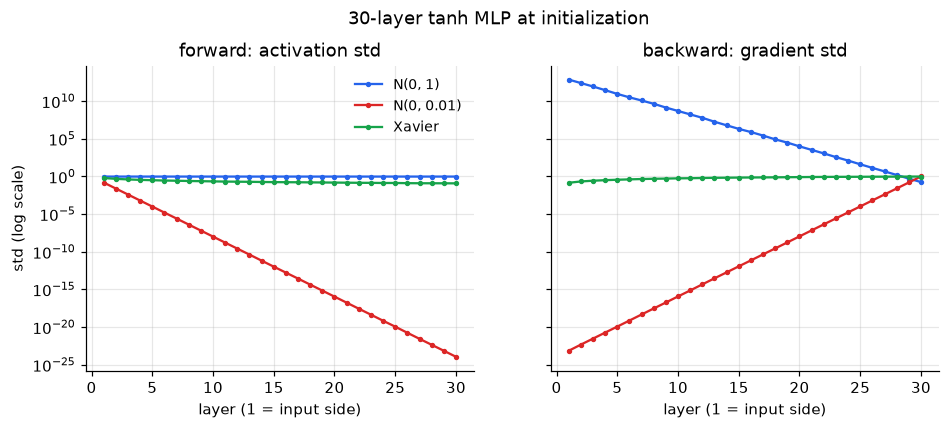

In [3]:
def signal_per_layer(act, init, depth=30, width=256, batch=512):
    """Run a random batch through a deep MLP at initialization.
    Returns the std of the activations (forward) and of the gradient (backward) at each layer."""
    torch.manual_seed(0)
    weights = [init(torch.empty(width, width)) for _ in range(depth)]
    h = torch.randn(batch, width, requires_grad=True)
    pre, post = [], []
    for W in weights:
        z = h @ W.T
        z.retain_grad()  # keep the gradient with respect to each pre-activation
        h = act(z)
        pre.append(z)
        post.append(h)
    (h * torch.randn_like(h)).sum().backward()  # a random gradient of std 1 arrives at the top
    forward = [p.std().item() for p in post]
    backward = [z.grad.std().item() for z in pre]
    return forward, backward


inits = {
    "N(0, 1)": lambda w: nn.init.normal_(w, 0, 1.0),
    "N(0, 0.01)": lambda w: nn.init.normal_(w, 0, 0.01),
    "Xavier": nn.init.xavier_normal_,
    "He": lambda w: nn.init.kaiming_normal_(w, nonlinearity="relu"),
}


def plot_signal(act, names, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
    results = {}
    for name in names:
        fwd, bwd = signal_per_layer(act, inits[name])
        results[name] = (fwd, bwd)
        ax1.semilogy(range(1, 31), fwd, marker="o", ms=2.5, label=name)
        ax2.semilogy(range(1, 31), bwd, marker="o", ms=2.5, label=name)
    ax1.set(title="forward: activation std", xlabel="layer (1 = input side)", ylabel="std (log scale)")
    ax2.set(title="backward: gradient std", xlabel="layer (1 = input side)")
    ax1.legend(frameon=False, fontsize=9)
    fig.suptitle(title, y=1.02)
    print(f"{'init':12s} {'act std L1':>11s} {'act std L30':>12s} {'grad std L1':>12s} {'grad std L30':>13s}")
    for name, (fwd, bwd) in results.items():
        print(f"{name:12s} {fwd[0]:11.2e} {fwd[-1]:12.2e} {bwd[0]:12.2e} {bwd[-1]:13.2e}")
    return results


tanh_results = plot_signal(torch.tanh, ["N(0, 1)", "N(0, 0.01)", "Xavier"], "30-layer tanh MLP at initialization")

#### Why it worked: a post-mortem

**The fan-in rule keeps the signal in a usable range.** With N(0, 0.01), the forward signal collapses by many orders of magnitude, and so does the gradient reaching the first layer: those layers would not learn. With N(0, 1), the forward signal saturates and the backward gradient explodes. Xavier sits between them, and both curves stay within about one order of magnitude over 30 layers. **[established]**

**Xavier is not perfect for tanh, and our plot shows it.** The forward signal still drifts down, from 0.63 at layer 1 to 0.12 at layer 30, because tanh is slightly contractive: its slope is below 1 everywhere except at zero, so every layer loses a little variance. The decay is slow (polynomial in depth rather than exponential), which is why Xavier was enough for the depths of 2010. **[established]**

**There is a sharp boundary between the two failures.** Poole et al. (2016) and Schoenholz et al. (2017) showed that deep tanh networks sit in an "ordered" phase (signals shrink) or a "chaotic" phase (signals and gradients blow up) depending on the weight scale, and that only near the boundary, the *edge of chaos*, can very deep networks be trained. Xavier puts the network close to that boundary. **[established]**

### Step 2 (major): He initialization for ReLU

#### The idea

The Xavier derivation assumes the activation passes the signal through unchanged near zero. ReLU does not: it sets every negative input to zero. For a symmetric input, half the units output zero, so the second moment of the output is half that of the input, `\(\mathbb{E}[\mathrm{ReLU}(z)^2] = \tfrac{1}{2}\mathrm{Var}(z)\)`. Under Xavier every ReLU layer therefore halves the signal, and 30 layers shrink it by `\(2^{-30} \approx 10^{-9}\)` in variance. He et al. (2015) fixed this by doubling the weight variance.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equation: He (Kaiming) initialization</p><div class="mlx-eq">$$\mathrm{Var}(z_{l}) = n_{\text{in}}\,\mathrm{Var}(w)\,\tfrac{1}{2}\,\mathrm{Var}(z_{l-1}) \quad\Longrightarrow\quad \mathrm{Var}(w) = \frac{2}{n_{\text{in}}}$$</div><p class="mlx-eq__where">The factor \(\tfrac{1}{2}\) is the fraction of the signal's energy that survives a ReLU. He et al. used this to train a 30-layer plain ReLU network that Xavier initialization could not train.</p></div>

#### Experiment: the signal, then training

First the same probe as in step 1, with ReLU and all four initializations.

init          act std L1  act std L30  grad std L1  grad std L30
N(0, 1)         9.35e+00     1.76e+31     1.94e+30      6.99e-01
N(0, 0.01)      9.35e-02     1.76e-29     1.94e-28      6.99e-01
Xavier          5.84e-01     1.32e-05     2.34e-05      6.99e-01
He              8.27e-01     4.34e-01     5.41e-01      6.99e-01


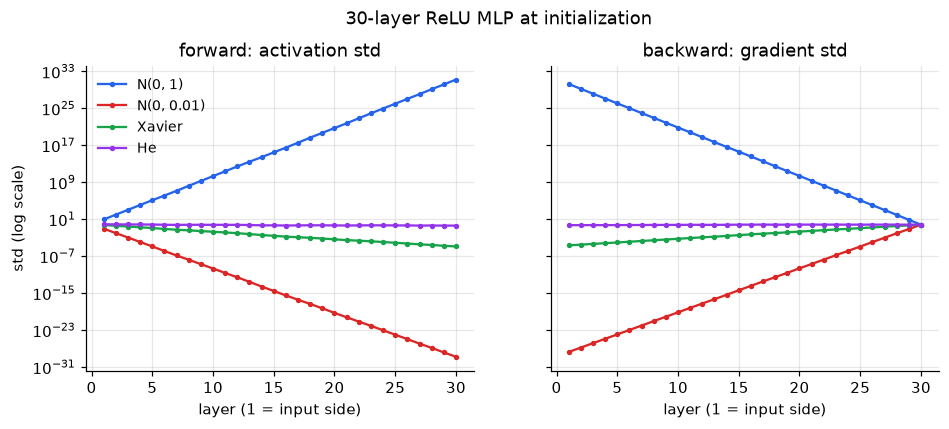

In [4]:
relu_results = plot_signal(F.relu, list(inits), "30-layer ReLU MLP at initialization")

A clean signal at step zero is a means, not the goal. Does it decide whether the network *trains*? We now train each of the eight combinations (tanh or ReLU, four initializations) for 400 steps of SGD with momentum on a synthetic task: classify 32-dimensional points into 8 Gaussian clusters. The network is 30 layers deep and 128 wide, with no normalization and no residual connections, so nothing but the initialization stands between it and a vanishing signal.

tanh  N(0, 1)     first loss      2.77   final loss    2.19   val accuracy 0.120


tanh  N(0, 0.01)  first loss      2.08   final loss    2.08   val accuracy 0.125


tanh  Xavier      first loss      2.14   final loss  0.0161   val accuracy 0.987


tanh  He          first loss      2.31   final loss 0.00576   val accuracy 0.978


ReLU  N(0, 1)     first loss  1.16e+27   final loss     nan   val accuracy 0.122


ReLU  N(0, 0.01)  first loss      2.08   final loss    2.08   val accuracy 0.125


ReLU  Xavier      first loss      2.08   final loss    2.08   val accuracy 0.125


ReLU  He          first loss      2.69   final loss  0.0105   val accuracy 0.979


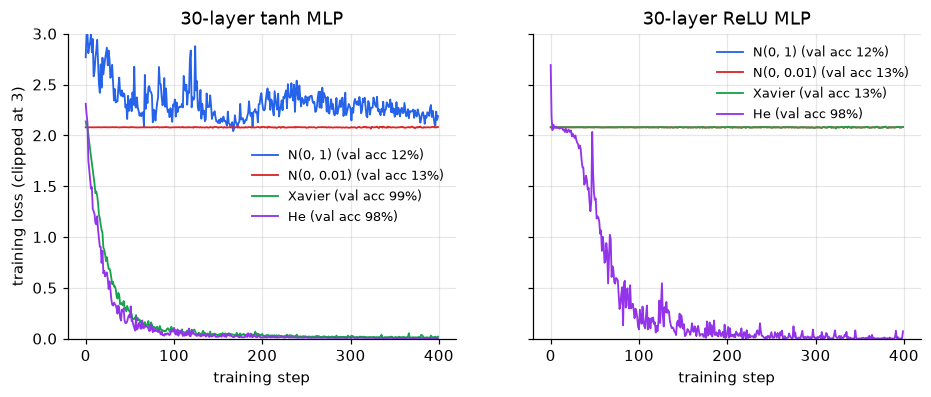

In [5]:
def make_clusters(n, gen, k=8, dim=32):
    centers = torch.randn(k, dim, generator=torch.Generator().manual_seed(0))
    y = torch.randint(k, (n,), generator=gen)
    return centers[y] + torch.randn(n, dim, generator=gen), y


gen = torch.Generator().manual_seed(1)
X_train, y_train = make_clusters(4096, gen)
X_val, y_val = make_clusters(2048, gen)


def deep_mlp(act, init, depth=30, width=128, d_in=32, n_classes=8):
    torch.manual_seed(0)
    layers, d = [], d_in
    for _ in range(depth):
        lin = nn.Linear(d, width)
        init(lin.weight)
        nn.init.zeros_(lin.bias)
        layers += [lin, act()]
        d = width
    head = nn.Linear(width, n_classes)
    nn.init.xavier_normal_(head.weight)
    nn.init.zeros_(head.bias)
    return nn.Sequential(*layers, head)


def train_classifier(model, steps=400, lr=0.003):
    opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    gen = torch.Generator().manual_seed(2)
    losses = []
    for _ in range(steps):
        idx = torch.randint(len(X_train), (128,), generator=gen)
        loss = F.cross_entropy(model(X_train[idx]), y_train[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    with torch.no_grad():
        acc = (model(X_val).argmax(1) == y_val).float().mean().item()
    return losses, acc


fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
train_results = {}
for ax, (act_name, act) in zip(axes, [("tanh", nn.Tanh), ("ReLU", nn.ReLU)]):
    for name, init in inits.items():
        losses, acc = train_classifier(deep_mlp(act, init))
        train_results[act_name, name] = (losses, acc)
        final = float(np.mean(losses[-20:]))
        ax.plot(np.clip(losses, 0, 3), label=f"{name} (val acc {acc:.0%})", lw=1.2)
        print(f"{act_name:5s} {name:11s} first loss {losses[0]:9.3g}   final loss {final:7.3g}   val accuracy {acc:.3f}")
    ax.set(title=f"30-layer {act_name} MLP", xlabel="training step", ylim=(0, 3))
    ax.legend(frameon=False, fontsize=8.5)
axes[0].set_ylabel("training loss (clipped at 3)");

#### Why it worked: a post-mortem

**The probe predicts the training outcome.** Every network whose signal or gradient vanished or exploded at step zero failed to learn: with 8 classes, chance accuracy is 12.5%, and that is where they stayed. Every network whose signal kept its scale trained to near-perfect accuracy. For ReLU, only He initialization works; Xavier's slow halving is enough to stop a 30-layer network. **[established]** for this setting, and it is the result He et al. (2015) reported for their 30-layer network.

**Tanh is more forgiving than ReLU.** Tanh trains under both Xavier and He: because tanh is bounded, the larger He weights cannot make the signal explode, they only push some units closer to saturation. ReLU is unbounded and has no such brake: a variance factor of 1.0 per layer is the only stable point. **[established]**

**Why is ReLU's exploding run so violent?** Under N(0, 1), each ReLU layer multiplies the variance by 128, so the first loss is astronomically large and the first update produces NaNs. Gradient clipping (chapter 9) would contain the update, but not the fact that the forward pass is meaningless. **[established]**

**Today, initialization is one of three safeguards.** Modern Transformers combine fan-in initialization with normalization layers (chapter 6) and residual connections (chapter 7), which together keep the signal in range even when the initialization is slightly off. GPT-2 additionally shrinks the output projection of each residual branch by `\(1/\sqrt{2L}\)` for `L` blocks, so the residual stream does not grow with depth. **[established]**

### Step 3 (major): dropout and weight decay

#### The problem before

Initialization decides whether a network can fit its training data. The next failure comes from fitting it *too* well. A network with far more parameters than training examples can memorize the training set, labels and noise included, and then it predicts poorly on anything new. In 2012 this was the binding problem for image and speech models trained on labelled datasets of a few hundred thousand examples. Zhang et al. (2017) later made the point vividly: standard image networks can fit randomly shuffled labels perfectly.

#### The idea

- **Dropout** (Hinton et al., 2012; Srivastava et al., 2014). At each training step, set each hidden unit to zero with probability `p`, and scale the survivors by `1/(1-p)` so the expected activation is unchanged. At test time, use every unit. A unit can no longer depend on a particular partner being present, so features have to be spread over many units. Hinton described it as training an ensemble of `\(2^{n}\)` thinned networks that share weights and averaging them at test time.
- **Weight decay** (Hanson and Pratt, 1988; Krogh and Hertz, 1991). At each step, shrink every weight towards zero by a small fraction. Large weights become expensive, so the network prefers smoother functions. With Adam it matters how the shrinkage is applied; AdamW applies it directly to the weights (chapter 9).
- **Data augmentation**, used alongside dropout in AlexNet (Krizhevsky et al., 2012), regularizes from the data side: random crops and flips create new training examples the model cannot simply memorize. It has no clean equivalent for text, so we do not test it here.

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: dropout and decoupled weight decay</p><div class="mlx-eq">$$\tilde h = \frac{m \odot h}{1 - p},\ \ m_i \sim \mathrm{Bernoulli}(1 - p) \qquad\qquad w \leftarrow w - \eta\,\lambda\,w - \eta\,\mathrm{update}(g)$$</div><p class="mlx-eq__where">\(m\) is a fresh random mask at every step; dividing by \(1-p\) keeps \(\mathbb{E}[\tilde h] = h\). In the weight decay update, \(\eta\) is the learning rate, \(\lambda\) the decay strength and \(\mathrm{update}(g)\) the optimizer's step from the gradient.</p></div>

#### Minimal implementation

PyTorch's `nn.Dropout` does exactly the masking and rescaling above, and only in training mode (`model.train()`); `model.eval()` switches it off. Our model is a small character-level MLP in the style of Bengio et al. (2003): embed the previous 16 characters, concatenate, and pass them through two hidden layers of 512 units to predict the next character.

In [6]:
CTX = 16  # characters of context


def windows(ids):
    """Every (16 characters, next character) pair in a stretch of text."""
    X = torch.stack([ids[i : i + CTX] for i in range(len(ids) - CTX)])
    return X, ids[CTX:]


X_tiny, y_tiny = windows(train_ids[:20_000])   # only 20k characters to learn from
X_held, y_held = windows(val_ids[:4_016])      # held-out text, never trained on
eval_idx = torch.randperm(len(X_tiny), generator=torch.Generator().manual_seed(0))[:4_000]


class CharMLP(nn.Module):
    def __init__(self, vocab, emb=24, hidden=512, p=0.0):
        super().__init__()
        self.emb = nn.Embedding(vocab, emb)
        self.net = nn.Sequential(
            nn.Linear(CTX * emb, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p),
            nn.Linear(hidden, vocab),
        )

    def forward(self, x):
        return self.net(self.emb(x).flatten(1))


print(f"parameters: {mlexp.count_params(CharMLP(tok.vocab_size)):,} for {len(X_tiny):,} training examples")

parameters: 494,681 for 19,984 training examples


#### Experiment: a model that can memorize its data

The model has about 25 times more parameters than training examples, so it will overfit. We train it four times for 1,500 steps with AdamW: with no regularization, with dropout 0.2, with dropout 0.5, and with weight decay instead of dropout. The decay strength is 1.0, much larger than the 0.1 typical for LLMs, because with AdamW the weights shrink by the learning rate times the decay per step, here 0.2% per step.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">All four runs start from the same weights. Which reaches the lowest training loss, which the lowest validation loss, and what happens to the unregularized model's validation loss as training continues?</p><details><summary>Show what happened</summary><p>The unregularized model reaches the lowest training loss (0.115) and the worst validation loss: it bottoms out at 2.756 early and then climbs to 5.40 as the model memorizes. Dropout 0.5 (2.529) and weight decay (2.576) give the best validation losses and the smallest gaps.</p></details></div>

no regularization  final train 0.115  final val 5.402  best val 2.756  gap 5.29  (12s)


dropout 0.2        final train 0.259  final val 4.023  best val 2.687  gap 3.76  (17s)


dropout 0.5        final train 1.101  final val 2.667  best val 2.529  gap 1.57  (18s)


weight decay 1.0   final train 1.065  final val 2.691  best val 2.576  gap 1.63  (12s)


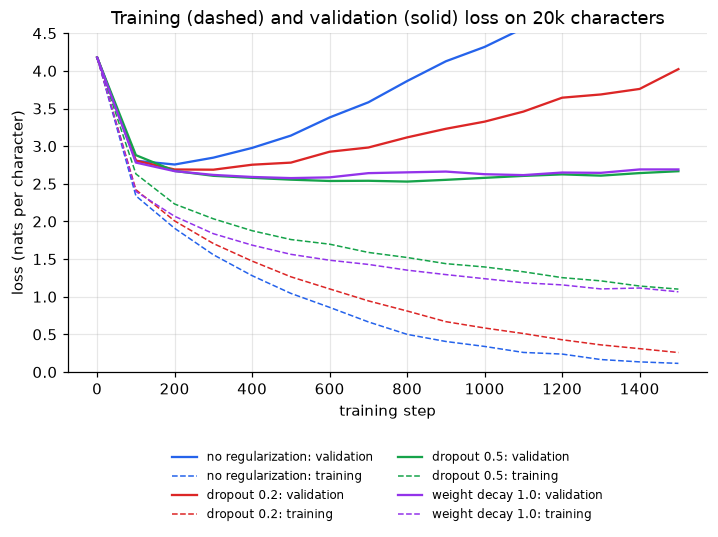

In [7]:
def train_char_mlp(p=0.0, weight_decay=0.0, steps=1500, lr=2e-3, eval_every=100):
    torch.manual_seed(0)
    model = CharMLP(tok.vocab_size, p=p)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    gen = torch.Generator().manual_seed(0)
    hist = {"step": [], "train": [], "val": []}
    for step in range(steps + 1):
        if step % eval_every == 0:
            model.eval()  # dropout off for evaluation
            with torch.no_grad():
                hist["step"].append(step)
                hist["train"].append(F.cross_entropy(model(X_tiny[eval_idx]), y_tiny[eval_idx]).item())
                hist["val"].append(F.cross_entropy(model(X_held), y_held).item())
            model.train()
        if step == steps:
            break
        idx = torch.randint(len(X_tiny), (128,), generator=gen)
        loss = F.cross_entropy(model(X_tiny[idx]), y_tiny[idx])
        opt.zero_grad()
        loss.backward()
        opt.step()
    return hist


reg_runs = {
    "no regularization": dict(),
    "dropout 0.2": dict(p=0.2),
    "dropout 0.5": dict(p=0.5),
    "weight decay 1.0": dict(weight_decay=1.0),
}
reg_hist = {}
fig, ax = plt.subplots(figsize=(7.5, 4))
for (name, kw), color in zip(reg_runs.items(), mlexp.plot.PALETTE):
    t0 = time.time()
    h = reg_hist[name] = train_char_mlp(**kw)
    ax.plot(h["step"], h["val"], color=color, label=f"{name}: validation")
    ax.plot(h["step"], h["train"], color=color, ls="--", lw=1, label=f"{name}: training")
    print(f"{name:18s} final train {h['train'][-1]:.3f}  final val {h['val'][-1]:.3f}  "
          f"best val {min(h['val']):.3f}  gap {h['val'][-1] - h['train'][-1]:.2f}  ({time.time() - t0:.0f}s)")
ax.set(xlabel="training step", ylabel="loss (nats per character)", ylim=(0, 4.5),
       title="Training (dashed) and validation (solid) loss on 20k characters")
ax.legend(frameon=False, fontsize=8, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.2));

#### Why it worked: a post-mortem

**Without regularization the model memorizes.** Its training loss falls far below anything a character model can achieve on Shakespeare it has not seen, while its validation loss turns around after a few hundred steps and keeps rising. The model has learned the 20,000 training characters rather than English. **[established]**

**Dropout trades training fit for generalization.** Each step trains a different random half of the network, so no single unit can store a specific training example and rely on its neighbours to decode it. Training loss stays higher and validation loss stays lower. The stronger the dropout, the smaller the gap. **[established]** Whether the ensemble interpretation is the right explanation, rather than dropout acting as a noise-based penalty on the weights (Wager et al., 2013), is debated; both views predict the same direction. **[likely]**

**Weight decay works through a different route.** It does not add noise. It limits how large the weights can grow, and memorizing 20,000 arbitrary continuations needs large, finely tuned weights. In our run it reaches a validation loss close to strong dropout. **[established]** for this run; the right strength depends heavily on the learning rate and run length.

**Why LLMs often skip dropout.** Our model sees each training example about 10 times. A large language model in pretraining sees most tokens about once, so there is little opportunity to memorize, and dropout mostly slows learning. Many recent LLMs pretrain with dropout set to zero (PaLM reports this explicitly) but keep weight decay, which in that regime seems to act more on optimization than on overfitting. **[likely]**

### Step 4 (major): muP, hyperparameters that transfer across width

#### The problem before

He initialization keeps the signal the right size at step zero, for any width. But the best *learning rate* still changes with width, and tuning it on a large model is expensive. Practitioners tuned on small models and extrapolated, which often failed. Yang and Hu (2021) asked a sharper question: as the width grows, how big is the change in each layer's output caused by one training step?

#### The idea

Consider a hidden layer `\(z = W h\)` with width `n`. At initialization, `z` sums `n` random terms that point in random directions, so its size grows like `\(\sqrt{n}\)`, and the `\(1/\sqrt{n}\)` in the fan-in scaling cancels it. An update is different. The gradient of `W` is an outer product with the input `h`, so the change `\(\Delta W h\)` sums `n` terms that all *agree in sign*. Under Adam, each weight moves by about the learning rate `\(\eta\)` whatever the gradient's size, so `\(\Delta W h\)` grows like `\(n\,\eta\)`, not `\(\sqrt{n}\,\eta\)`. Double the width and every step changes the hidden features twice as much. Hence the best learning rate for standard models falls as they get wider.

The **Maximal Update Parametrization (muP)** rescales each layer so that every layer's features change by an amount independent of the width:

<div class="mlx-box mlx-box--eq"><p class="mlx-box__label">Key equations: muP for Adam (Yang et al., 2022)</p><div class="mlx-eq">$$\text{hidden } W:\ \ \mathrm{Var}(w) \propto \frac{1}{n},\ \ \eta_W = \eta\,\frac{n_0}{n} \qquad \text{output } W:\ \ w = 0 \text{ at start},\ \ \eta_W = \eta\,\frac{n_0}{n} \qquad \text{input } W:\ \ \eta_W = \eta$$</div><p class="mlx-eq__where">\(n\) is the width and \(n_0\) a base width at which muP and standard scaling coincide. The input layer's fan-in does not change with width, so it keeps the base learning rate. Starting the output at zero keeps the initial logits from depending on width and lets the hidden features, not the random readout, drive learning.</p></div>

#### Minimal implementation

Our test model is a character-level MLP with an 8-character context and three hidden layers. Standard parametrization (SP) uses He initialization and one learning rate for every layer. muP changes only two things: the output layer starts at zero, and the hidden and output matrices get their learning rate multiplied by `64 / width`. Both are a few lines in the optimizer's parameter groups.

In [8]:
CTX4, EMB4, BASE_WIDTH = 8, 16, 64


class WideMLP(nn.Module):
    def __init__(self, vocab, width):
        super().__init__()
        self.emb = nn.Embedding(vocab, EMB4)
        self.inp = nn.Linear(CTX4 * EMB4, width)   # fan-in fixed: does not grow with width
        self.hidden = nn.ModuleList([nn.Linear(width, width), nn.Linear(width, width)])
        self.out = nn.Linear(width, vocab, bias=False)

    def forward(self, x):
        h = F.relu(self.inp(self.emb(x).flatten(1)))
        for layer in self.hidden:
            h = F.relu(layer(h))
        return self.out(h)


def build(width, mup, lr):
    torch.manual_seed(0)
    model = WideMLP(tok.vocab_size, width)
    for layer in [model.inp, *model.hidden]:
        nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")  # He init in both
        nn.init.zeros_(layer.bias)
    nn.init.normal_(model.emb.weight, 0, 1)
    if mup:
        nn.init.zeros_(model.out.weight)  # muP: the readout starts at zero
    else:
        nn.init.normal_(model.out.weight, 0, width ** -0.5)
    scale = BASE_WIDTH / width if mup else 1.0  # muP: hidden and output LR shrink with width
    width_params = [p for l in model.hidden for p in [l.weight]] + [model.out.weight]
    other_params = [model.emb.weight, model.inp.weight, model.inp.bias] + [l.bias for l in model.hidden]
    opt = torch.optim.Adam([{"params": other_params, "lr": lr},
                            {"params": width_params, "lr": lr * scale}])
    return model, opt


def final_loss(width, mup, lr, steps=250, batch=128):
    """Train briefly; return the mean loss over the last 50 batches (fresh text, so close to validation loss)."""
    model, opt = build(width, mup, lr)
    gen = torch.Generator().manual_seed(0)
    losses = []
    for _ in range(steps):
        x, y = mlexp.get_batch(train_ids, batch, CTX4, gen)
        loss = F.cross_entropy(model(x), y[:, -1])  # predict the character after the 8-character window
        if not torch.isfinite(loss):
            return float("nan")
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return float(np.mean(losses[-50:]))

#### Experiment: sweep the learning rate at three widths

For widths 64, 256 and 1024, we sweep the learning rate over nine powers of two and record the loss after 250 steps. The batches come from a million characters of text, so the model sees almost every example once and the training loss is a fair proxy for validation loss. Width 1024 is the slow part; the sweep takes three to four minutes.

<div class="mlx-box mlx-box--predict"><p class="mlx-box__label">Predict first</p><p class="mlx-predict__q">Under standard parametrization, does the best learning rate for width 1024 sit above, at, or below the best for width 64? And under muP?</p><details><summary>Show what happened</summary><p>Under SP the best learning rate falls as the model widens: 2<sup>-7</sup> at width 64, 2<sup>-8</sup> at 256 and 2<sup>-9</sup> at 1024. Under muP it stays at 2<sup>-7</sup> at all three widths, and the wider model is better at every learning rate near the optimum.</p></details></div>

sweep took 215s

SP  width   64: best lr 2^-7  loss 2.407   (3.35 3.19 2.99 2.72 2.50 2.41 2.44 2.54 2.78)
SP  width  256: best lr 2^-8  loss 2.321   (2.97 2.76 2.55 2.39 2.32 2.33 2.44 2.58 3.04)
SP  width 1024: best lr 2^-9  loss 2.312   (2.50 2.38 2.33 2.31 2.33 2.50 2.74 3.13 3.33)
muP width   64: best lr 2^-7  loss 2.383   (3.16 2.96 2.75 2.56 2.42 2.38 2.44 2.52 2.97)
muP width  256: best lr 2^-7  loss 2.262   (3.11 2.86 2.63 2.45 2.32 2.26 2.28 2.35 2.53)
muP width 1024: best lr 2^-7  loss 2.199   (3.08 2.79 2.57 2.40 2.27 2.20 2.20 2.26 2.38)


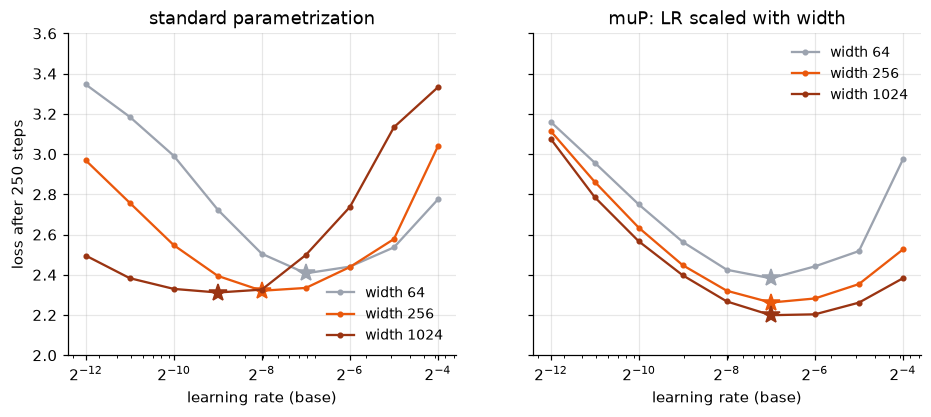

In [9]:
lrs = [2.0 ** k for k in range(-12, -3)]
widths = [64, 256, 1024]
sweep = {}
t0 = time.time()
for mup in [False, True]:
    for width in widths:
        sweep[mup, width] = [final_loss(width, mup, lr) for lr in lrs]
print(f"sweep took {time.time() - t0:.0f}s\n")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, mup in zip(axes, [False, True]):
    for width, color in zip(widths, ["#9ca3af", "#ea580c", "#9a3412"]):
        losses = np.array(sweep[mup, width])
        best = int(np.nanargmin(losses))
        ax.plot(lrs, losses, marker="o", ms=3, color=color, label=f"width {width}")
        ax.plot(lrs[best], losses[best], marker="*", ms=12, color=color)
        print(f"{'muP' if mup else 'SP ':3s} width {width:4d}: best lr 2^{int(math.log2(lrs[best]))}"
              f"  loss {losses[best]:.3f}   (" + " ".join(f"{l:.2f}" for l in losses) + ")")
    ax.set(xscale="log", xlabel="learning rate (base)", ylim=(2.0, 3.6),
           title="muP: LR scaled with width" if mup else "standard parametrization")
    ax.set_xticks(lrs[::2], [f"$2^{{{int(math.log2(l))}}}$" for l in lrs[::2]])
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("loss after 250 steps");

#### Why it worked: a post-mortem

**Under standard parametrization, the optimum moves.** The best learning rate drops by about a factor of two for every fourfold increase in width, and using the width-64 optimum on the width-1024 model costs a noticeably worse loss. This is the `\(n\,\eta\)` effect: wider layers sum more aligned update terms, so the same learning rate is effectively larger. **[established]**, matching Yang et al. (2022).

**Under muP, the optimum stays put, and wider is reliably better.** Dividing the hidden and output learning rates by the width cancels the growth in update size, so the loss curves line up and the best base learning rate is the same at every width. In the paper this let the authors tune a 40-million-parameter proxy and transfer the settings to a 6.7-billion-parameter GPT-3, which then outperformed the published GPT-3 model of the same size. **[established]**

**muP's widest model is also the best model.** At its best learning rate, the standard width-1024 model is barely better than width 256 (2.321 against 2.312), while under muP it improves clearly (2.199). The zero readout and the smaller hidden learning rate let the wide model keep learning features instead of taking oversized steps. This is a single seed, so treat it as suggestive. **[likely]**

**What muP does not cover.** It is derived for width. Depth, batch size, training length and weight decay all shift the optimum too, and muP alone does not transfer across them; later work (for example depth-muP, 2023) extends the idea to depth. Our sweep is also small: three widths, one seed, 250 steps. The shift is clear, but the exact factor per width is an illustration, not a measurement. **[likely]**

**Adoption.** Some open model families, such as Cerebras-GPT and MiniCPM, report training with muP. Many other labs instead fit empirical scaling laws for the learning rate across model size (chapter 12). Which approach wins is not settled. **[speculative]**

## Recap

<div class="mlx-box mlx-box--objectives"><p class="mlx-box__label">Recap</p><p>You should now be able to:</p><ol><li>Derive the Xavier and He variances from the rule that each layer should multiply the signal's variance by 1.</li><li>Measure the forward and backward signal of a deep network at step zero and predict from it whether the network will train.</li><li>Explain how dropout and weight decay reduce the gap between training and validation loss, and why LLM pretraining often drops dropout.</li><li>Explain why fan-in initialization does not fix the learning rate across width, and what muP changes to fix it.</li></ol></div>

<div class="mlx-box mlx-box--check"><p class="mlx-box__label">Check your understanding</p><details><summary>A layer has 512 inputs and uses ReLU. What standard deviation should its weights have, and where does each factor come from?</summary><p>He initialization gives variance 2/512, so a standard deviation of 1/16 = 0.0625. The 1/512 cancels the sum over 512 inputs; the 2 compensates for ReLU zeroing half of its inputs, which halves the signal's energy.</p></details><details><summary>A 30-layer ReLU network uses Xavier initialization with equal fan-in and fan-out. By roughly what factor does the activation variance shrink from the first to the last layer?</summary><p>Each layer multiplies the variance by fan-in &times; (1/fan-in) &times; 1/2 = 1/2, so 30 layers give \(2^{-30} \approx 10^{-9}\) in variance, or about \(3 \times 10^{-5}\) in standard deviation. That is the order of magnitude of the decay our probe measured.</p></details><details><summary>Why does the best Adam learning rate fall with width under standard parametrization, even though fan-in initialization keeps the signal the same size at every width?</summary><p>Initialization sums random, uncorrelated terms, whose total grows like the square root of the width. An update is an outer product with the layer's input, so its effect sums width many terms of the same sign, which grows linearly with width. Adam makes each weight's step about the learning rate, so the change per step grows with width. muP divides the learning rate by the width to cancel it.</p></details></div>

## Further reading

- LeCun, Bottou, Orr and M&uuml;ller, 1998, [Efficient BackProp](https://doi.org/10.1007/3-540-49430-8_2): the 1/fan-in rule and many other practical tricks.
- Glorot and Bengio, 2010, [Understanding the difficulty of training deep feedforward neural networks](https://proceedings.mlr.press/v9/glorot10a.html): Xavier initialization.
- He, Zhang, Ren and Sun, 2015, [Delving Deep into Rectifiers](https://arxiv.org/abs/1502.01852): He initialization and PReLU.
- Hinton, Srivastava, Krizhevsky, Sutskever and Salakhutdinov, 2012, [Improving neural networks by preventing co-adaptation of feature detectors](https://arxiv.org/abs/1207.0580): dropout.
- Srivastava et al., 2014, [Dropout: A Simple Way to Prevent Neural Networks from Overfitting](https://jmlr.org/papers/v15/srivastava14a.html).
- Schoenholz, Gilmer, Ganguli and Sohl-Dickstein, 2017, [Deep Information Propagation](https://arxiv.org/abs/1611.01232): ordered and chaotic phases, and the edge of chaos.
- Zhang, Bengio, Hardt, Recht and Vinyals, 2017, [Understanding deep learning requires rethinking generalization](https://arxiv.org/abs/1611.03530).
- Yang, Hu, Babuschkin, Sidor, Liu, Farhi, Ryder, Pachocki, Chen and Gao, 2022, [Tensor Programs V: Tuning Large Neural Networks via Zero-Shot Hyperparameter Transfer](https://arxiv.org/abs/2203.03466): muP and muTransfer.